In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm


In [ ]:
omegam,chi2=np.load("chi2_values.npy")
log_posterior= -0.5*chi2

In [ ]:
interp_log_posterior= interp1d(omegam,log_posterior, kind='cubic')


In [ ]:
def MCMC(x0, n_steps, x_min , x_max):
  #mi restituisce la catena e se ho scelto o non ho scelto il punto
  #ora implemento l'algoritmonek for
  chain=[]
  acceptance=[]
  chi2_chain=[]
  chain.append(x0)
  acceptance.append(True)
  chi2_chain.append(interp_log_posterior(x0))

  for i in tqdm(range(n_steps)):
    x_try= np.random.uniform(x_min,x_max)
    #quelli che sto considerando qua sono già logaritmi della likelihood
    f_try=interp_log_posterior(x_try)
    f_old=interp_log_posterior(chain[-1])
    #il -1 sta guardando l'ultimo elemento della lista i-1
    #chain[-1] corrisponde all'ultimo elemento aggiornato
    #confronto con il valore dello step precente
    log_ratio = f_try - f_old
    log_u = np.log(np.random.uniform())

    if log_u < log_ratio:
      chain.append(x_try)
      chi2_chain.append(f_try)
      acceptance.append(True)
    else:
      chain.append(chain[-1])
      chi2_chain.append(f_old)
      acceptance.append(False)
  return chain, chi2_chain, acceptance




In [ ]:
x_min= 0.23
x_max= 0.37
n_steps= 100000
#x0= 0.26
#parto da ancora più lontano
x0= 0.23
#lontano dal picco

chain, chi2_chain, acceptance= MCMC(x0, n_steps, x_min , x_max)

  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
print("ACCEPTANCE",np.sum(acceptance))

ACCEPTANCE 19715


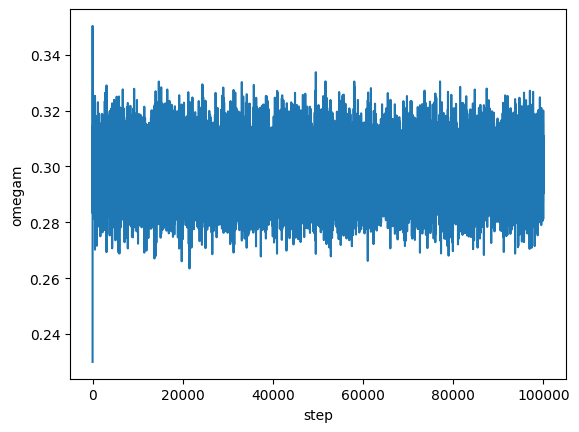

In [ ]:
plt.plot(range(len(chain)),chain)
plt.xlabel("step")
plt.ylabel("omegam")
plt.show()

prima deve capire come deve convergere dopo comincia ad oscillare attorno al valore del picco l'acceptance rate è di circa il 20% e dipende dalla q non deve in alcun modo influenzare il risultato.

come si può notare una funzione è fatta un pò a gradini questo è esattamente il processo di ripetizione del punto procedente quindi nonriusciva ad uscire era proprio nel momento in cui era dentro il picco preciso mentre nei punti lontani cambia subito.

non è un processo che si blocca nel centro in parte è random il fatto che si confronti con un numero random gli permette di esplorare tutta la funzione. sto inserendo una memoria nel programma la catena ci mette un po' a dimenticarsi. lo vedremo in più dimensioni e lo confronteremo con il rejection sampling.

In [ ]:
omega_m_media= np.mean(chain[:1000])
omega_m_std= np.std(chain)
print("Omega_m:", omega_m_media , "+/-", omega_m_std)

Omega_m: 0.2980865759467049 +/- 0.008758777706374432


In [ ]:
chain_no_burn = chain[:1000]
steps= [10,20,30,40,50,60,70,80,90,100]

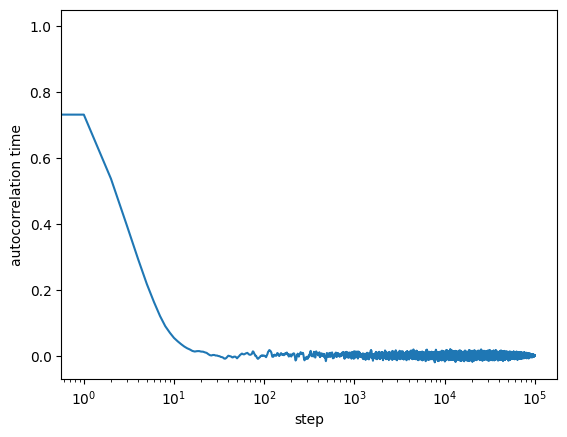

In [ ]:
def next_pow_two(n):
    i = 1
    while i < n:
        i = i << 1
    return i

def autocorr_func_1d(x, norm=True):
    x = np.atleast_1d(x)
    if len(x.shape) != 1:
        raise ValueError("invalid dimensions for 1D autocorrelation function")
    n = next_pow_two(len(x))

    # Compute the FFT and then (from that) the auto-correlation function
    f = np.fft.fft(x - np.mean(x), n=2 * n)
    acf = np.fft.ifft(f * np.conjugate(f))[: len(x)].real
    acf /= 4 * n
    #lo stesso calcolo della funzione di autocorrelazione nello spazio di fourier

    # Optionally normalize
    if norm:
        acf /= acf[0]

    return acf

acf= autocorr_func_1d(chain)
plt.semilogx(acf)
plt.xlabel("step")
plt.ylabel("autocorrelation time")
plt.show()

In [ ]:
chain = np.array(chain)
acf= autocorr_func_1d(chain[1000:-1:10])

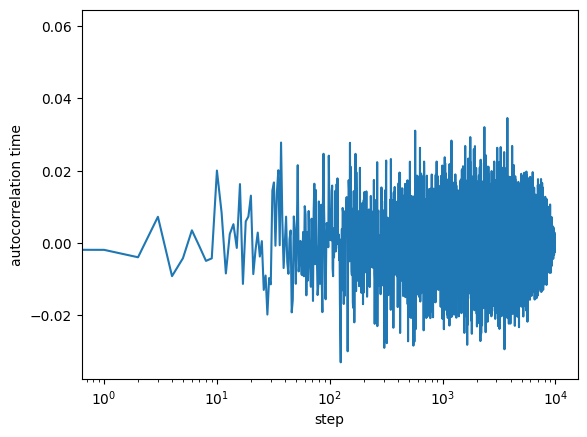

In [ ]:
plt.semilogx(acf[1:])
plt.xlabel("step")
plt.ylabel("autocorrelation time")
plt.show()